#Extracción del Archivo Tratado

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [178]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [179]:
datos = pd.read_csv('/content/TelecomX_Data.csv')
datos.sample(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
6824,9708-KFDBY,No,Male,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),20.55,20.55
3310,4726-DLWQN,No,Male,1,No,No,50,Yes,Yes,DSL,...,Yes,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),70.35,3454.60
5518,7785-RDVIG,No,Female,0,Yes,Yes,3,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.30,54.70
4541,6416-TVAIH,Yes,Male,0,Yes,Yes,1,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,68.50,68.50
1933,2811-POVEX,No,Female,1,Yes,Yes,23,Yes,No,Fiber optic,...,Yes,Yes,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),88.45,2130.55


In [180]:
datos.shape

(7032, 21)

In [181]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   objec

In [182]:
datos.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

#Eliminación de Columnas Irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [183]:
datos = datos.drop(columns = 'customerID')

In [184]:
datos.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [185]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7032 non-null   object 
 1   customer.gender            7032 non-null   object 
 2   customer.SeniorCitizen     7032 non-null   int64  
 3   customer.Partner           7032 non-null   object 
 4   customer.Dependents        7032 non-null   object 
 5   customer.tenure            7032 non-null   int64  
 6   phone.PhoneService         7032 non-null   object 
 7   phone.MultipleLines        7032 non-null   object 
 8   internet.InternetService   7032 non-null   object 
 9   internet.OnlineSecurity    7032 non-null   object 
 10  internet.OnlineBackup      7032 non-null   object 
 11  internet.DeviceProtection  7032 non-null   object 
 12  internet.TechSupport       7032 non-null   object 
 13  internet.StreamingTV       7032 non-null   objec

####Separación por variables

In [186]:
var_numerica = datos[['customer.SeniorCitizen', 'customer.tenure','account.Charges.Monthly','account.Charges.Total']]
var_numerica.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
0,0,9,65.6,593.30
1,0,9,59.9,542.40
2,0,4,73.9,280.85
3,1,13,98.0,1237.85
4,1,3,83.9,267.40


In [187]:
var_categorica = datos.drop(columns = var_numerica.columns)
var_categorica

,Churn,customer.gender,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod
0,No,Female,Yes,Yes,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check
1,No,Male,No,No,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check
2,Yes,Male,No,No,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check
3,Yes,Male,Yes,No,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
4,Yes,Female,Yes,No,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Female,No,No,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check
7028,Yes,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check
7029,No,Male,No,No,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check
7030,No,Male,Yes,Yes,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check


In [188]:
var_categorica = var_categorica.drop(columns = 'Churn')

In [189]:
var_numerica['Churn'] = datos['Churn'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_370/3564125038.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [190]:
var_numerica

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn
0,0,9,65.60,593.30,0
1,0,9,59.90,542.40,0
2,0,4,73.90,280.85,1
3,1,13,98.00,1237.85,1
4,1,3,83.90,267.40,1
...,...,...,...,...,...
7027,0,13,55.15,742.90,0
7028,0,22,85.10,1873.70,1
7029,0,2,50.30,92.75,0
7030,0,67,67.85,4627.65,0


#Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

In [191]:
corr_num = var_numerica.corr()
corr_num

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn
customer.SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
customer.tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
account.Charges.Monthly,0.219874,0.246862,1.000000,0.651065,0.192858
account.Charges.Total,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150541,-0.354049,0.192858,-0.199484,1.000000


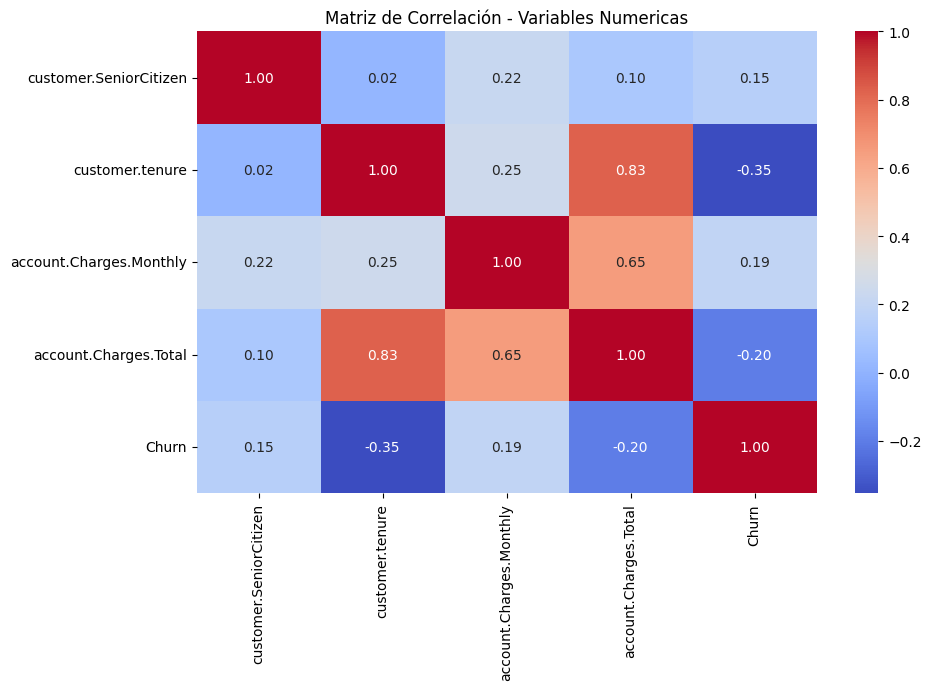

In [192]:
corr_matrix = corr_num

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numericas")
plt.show()


In [193]:
datos.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [194]:
datos = datos.drop(columns = ['account.Charges.Total'])

In [195]:
var_numerica = var_numerica.drop(columns = ['account.Charges.Total'])

In [196]:
corr_num = var_numerica.corr()
corr_num

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,Churn
customer.SeniorCitizen,1.000000,0.015683,0.219874,0.150541
customer.tenure,0.015683,1.000000,0.246862,-0.354049
account.Charges.Monthly,0.219874,0.246862,1.000000,0.192858
Churn,0.150541,-0.354049,0.192858,1.000000


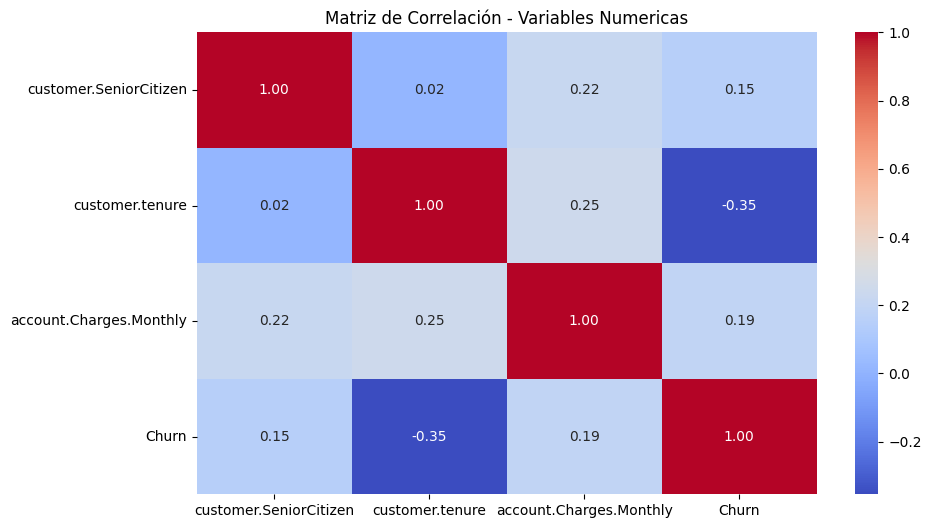

In [197]:
corr_matrix = corr_num

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numericas")
plt.show()

##Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [198]:
import plotly.express as px

In [199]:
px.box(datos, x = 'customer.tenure', color = 'Churn', title='Tiempo de permanencia como cliente')

In [200]:
px.box(datos, x = 'account.Charges.Monthly', color = 'Churn', title='Valor mensual cobrado')

In [201]:
for col in var_categorica:
    print(f"\n Variable: {col}")
    display(pd.crosstab(datos[col], datos["Churn"], normalize="index") * 100)


 Variable: customer.gender


Churn,No,Yes
customer.gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565



 Variable: customer.Partner


Churn,No,Yes
customer.Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065



 Variable: customer.Dependents


...

Churn,No,Yes
account.Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665



 Variable: account.PaperlessBilling


Churn,No,Yes
account.PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251



 Variable: account.PaymentMethod


Churn,No,Yes
account.PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [202]:
datos.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly'],
      dtype='object')

In [203]:
datos = datos.drop(columns = ['customer.gender', 'phone.PhoneService'])

In [204]:
var_categorica = var_categorica.drop(columns = ['customer.gender', 'phone.PhoneService'])

In [205]:
from sklearn.preprocessing import LabelEncoder

Dividimos los datos en datos de prueba y de entrenamiento

In [206]:
X = datos.drop(columns = 'Churn')
y = datos['Churn']

In [207]:
X

,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly
0,0,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,0,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,0,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,1,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,1,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7028,0,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7029,0,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7030,0,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [208]:
label_encoder = LabelEncoder()

In [209]:
y = label_encoder.fit_transform(y)

In [210]:
y

array([0, 0, 1, ..., 0, 0, 0])

#Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [211]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [212]:
columnas = X.columns

In [213]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['customer.Partner', 'customer.Dependents', 'phone.MultipleLines',
       'internet.InternetService', 'internet.OnlineSecurity',
       'internet.OnlineBackup', 'internet.DeviceProtection',
       'internet.TechSupport', 'internet.StreamingTV',
       'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod']
    ),
        remainder = 'passthrough',
        sparse_threshold=0,
        force_int_remainder_cols=False)

In [214]:
X = one_hot.fit_transform(X)

In [215]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__customer.Partner_Yes',
       'onehotencoder__customer.Dependents_Yes',
       'onehotencoder__phone.MultipleLines_No',
       'onehotencoder__phone.MultipleLines_No phone service',
       'onehotencoder__phone.MultipleLines_Yes',
       'onehotencoder__internet.InternetService_DSL',
       'onehotencoder__internet.InternetService_Fiber optic',
       'onehotencoder__internet.InternetService_No',
       'onehotencoder__internet.OnlineSecurity_No',
       'onehotencoder__internet.OnlineSecurity_No internet service',
       'onehotencoder__internet.OnlineSecurity_Yes',
       'onehotencoder__internet.OnlineBackup_No',
       'onehotencoder__internet.OnlineBackup_No internet service',
       'onehotencoder__internet.OnlineBackup_Yes',
       'onehotencoder__internet.DeviceProtection_No',
       'onehotencoder__internet.DeviceProtection_No internet service',
       'onehotencoder__internet.DeviceProtection_Yes',
       'onehotencoder__internet.TechSupport_No',
      

In [216]:
X

array([[ 1.  ,  1.  ,  1.  , ...,  0.  ,  9.  , 65.6 ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  9.  , 59.9 ],
       [ 0.  ,  0.  ,  1.  , ...,  0.  ,  4.  , 73.9 ],
       ...,
       [ 0.  ,  0.  ,  1.  , ...,  0.  ,  2.  , 50.3 ],
       [ 1.  ,  1.  ,  1.  , ...,  0.  , 67.  , 67.85],
       [ 1.  ,  1.  ,  0.  , ...,  0.  , 63.  , 59.  ]])

#Separación de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    stratify=y, random_state=42
)

#Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

In [218]:
datos['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [219]:
datos['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.734215
Yes,0.265785


In [220]:
datos['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.421502
Yes,26.578498


#Creación de Modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

###Dummy. Creamos una baseline.

In [221]:
from sklearn.metrics import classification_report

In [222]:
from sklearn.dummy import DummyClassifier

In [223]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)

dummy.score(X_test, y_test)

0.7341862117981521

###Árbol de decisión

In [224]:
from sklearn.tree import DecisionTreeClassifier

In [225]:
modelo_arbol = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state =5)
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=5)

In [263]:
y_prevista_train = modelo_arbol.predict(X_train)
print(classification_report(y_train, y_prevista_train))

              precision    recall  f1-score   support

           0       0.92      0.75      0.83      4130
           1       0.54      0.81      0.65      1495

    accuracy                           0.77      5625
   macro avg       0.73      0.78      0.74      5625
weighted avg       0.82      0.77      0.78      5625



In [226]:
y_prevista = modelo_arbol.predict(X_test)
print(classification_report(y_test, y_prevista))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [227]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

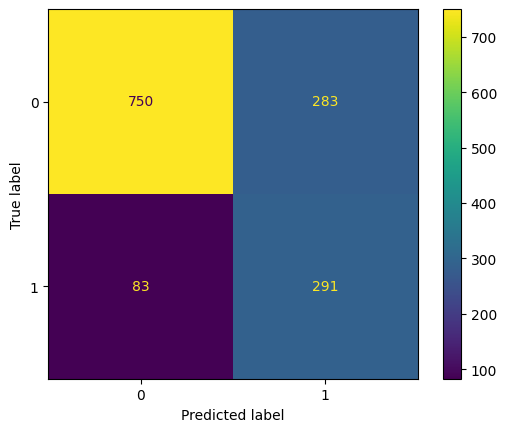

In [228]:
matriz_confusion = ConfusionMatrixDisplay.from_predictions(y_test,y_prevista);

In [267]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [283]:
valores_columnas = one_hot.get_feature_names_out(columnas)

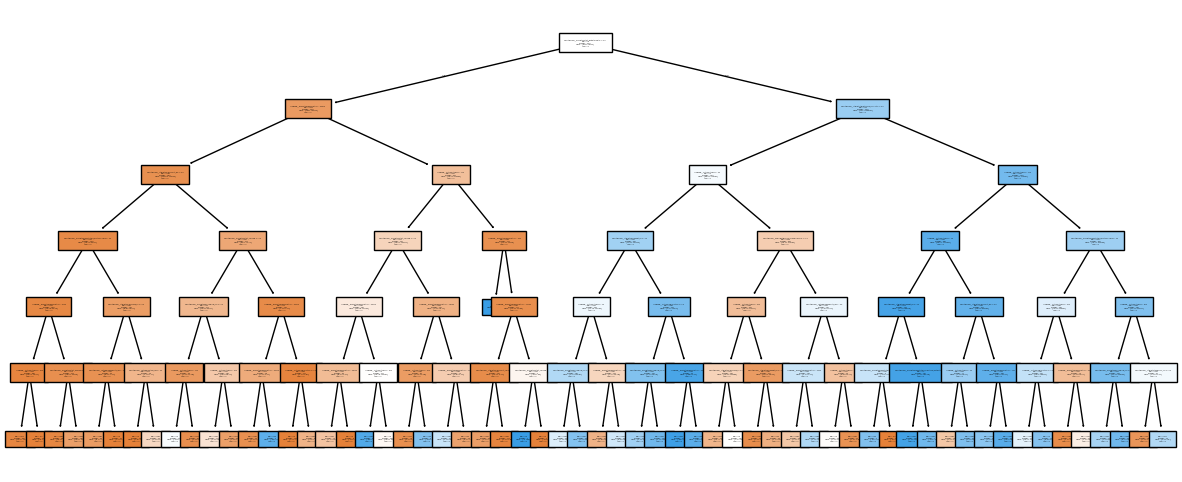

In [286]:
plt.figure(figsize = (15, 6))
plot_tree(modelo_arbol, filled = True, class_names = ['no', 'si'], fontsize = 1, feature_names = valores_columnas);

##Balanceo de Clases (opcional)

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

##Undersampling

In [229]:
from imblearn.pipeline import Pipeline as imbpipeline

In [230]:
from imblearn.under_sampling import NearMiss

In [231]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [232]:
modeloDTU = DecisionTreeClassifier(max_depth=6, random_state=42)
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('arbol',modelo_arbol)])
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados =cross_validate(pipeline,X,y,cv=skf,scoring='recall')

In [233]:
def intervalo_confianza(resultados):
  promedio = resultados['test_score'].mean()
  desvio_std = resultados['test_score'].std()
  return f'El intervalo de confianza es: [{promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}]'

In [234]:
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.5986032587681795,0.7058597596831688]'

In [235]:
modeloDTU.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [236]:
y_prevista_under = modeloDTU.predict(X_test)

In [237]:
print(classification_report(y_test, y_prevista_under))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.61      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



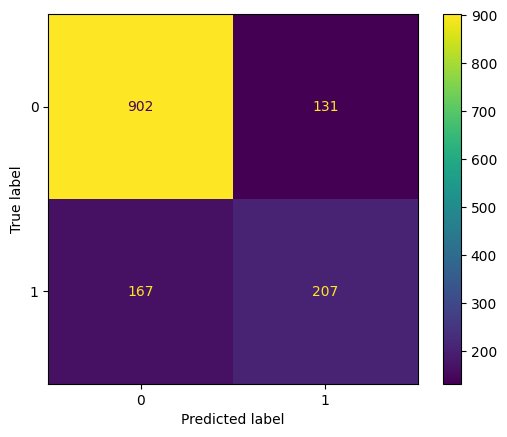

In [238]:
matriz_confusion = ConfusionMatrixDisplay.from_predictions(y_test,y_prevista_under);

###KNN

###Normalización

In [239]:
from sklearn.preprocessing import MinMaxScaler

In [240]:
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)

In [241]:
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.507042,0.020896
1,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.943662,0.808955
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.028169,0.553234
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.112676,0.504478
4,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.774648,0.467164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.915493,0.111443
5621,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.746479,0.609453
5622,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.957746,0.629353
5623,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.309859,0.013930


Modelo

In [242]:
from sklearn.neighbors import KNeighborsClassifier

In [243]:
knn = KNeighborsClassifier()

In [244]:
knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [245]:
X_test_normalizado = normalizacion.transform(X_test)

In [246]:
knn.score(X_test_normalizado, y_test)

0.7526652452025586

In [247]:
y_previsto_knn = knn.predict(X_test_normalizado)

In [248]:
print(classification_report(y_test, y_previsto_knn))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1033
           1       0.54      0.48      0.51       374

    accuracy                           0.75      1407
   macro avg       0.68      0.67      0.67      1407
weighted avg       0.75      0.75      0.75      1407



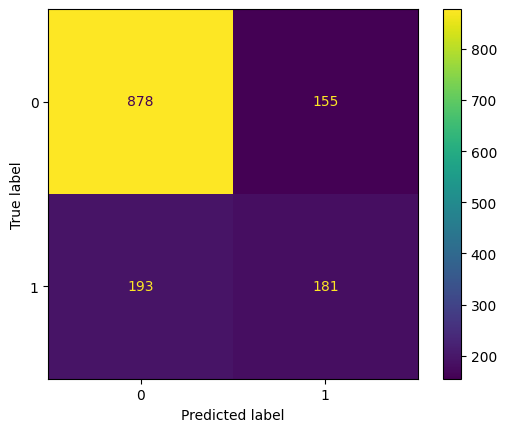

In [249]:
matriz_confusion = ConfusionMatrixDisplay.from_predictions(y_test,y_previsto_knn);

In [250]:
modelo = KNeighborsClassifier()
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('arbol',modelo)])
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados =cross_validate(pipeline,X,y,cv=skf,scoring='recall')

In [251]:
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.5542567784040388,0.6463855062943885]'

#Informe

El objetivo de este proyecto fue construir un pipeline robusto para anticipar la baja de clientes (Churn). Tras evaluar múltiples arquitecturas y técnicas de preprocesamiento, se seleccionó un modelo de Árbol de Decisión Optimizado que prioriza el Recall, logrando identificar preventivamente al 78% de los clientes en riesgo.

A través del análisis de importancia de variables y la visualización de la estructura del árbol, se identificaron las razones más probables por las cuales los clientes abandonan la empresa como el tipo de contrato, especialmente el mes a mes, el servicio de fibre óptica, la antigüedad (aumentando riesgo cuando los clientes son nuevos) y el método de pago de cheques electrónicos.

Se implementó eliminación de multicolinealidad, un manej del desbalanceo y validación cruzada.

El modelo desarrollado supera ampliamente la capacidad de detección de la baseline (azar). Aunque existe un margen de mejora en la precisión, la capacidad actual de capturar el 78% de los desertores proporciona a la empresa una ventaja competitiva crítica para realizar intervenciones preventivas y estabilizar su cartera de clientes.